In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

os.makedirs("results", exist_ok=True)
os.makedirs("paper_outputs/figures", exist_ok=True)

print("Project root:", os.getcwd())
print("Output folders ready.")

Project root: C:\Users\user\Desktop\Plant_Stress_Domain_Shift
Output folders ready.


In [2]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = MobileNet_V3_Small_Weights.DEFAULT
model = mobilenet_v3_small(weights=weights)

model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)

model_path = "models/mobilenetv3_small_plantvillage_20000.pth"
model.load_state_dict(torch.load(model_path, map_location=device))

model = model.to(device)
model.eval()

print("Device:", device)
print("MobileNetV3-Small 20,000 model loaded.")

Device: cpu
MobileNetV3-Small 20,000 model loaded.


In [3]:
image_size = 224

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class PlantStressDatasetWithPaths(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "image_path"]
        label = int(self.dataframe.loc[index, "label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image_tensor = self.transform(image)
        else:
            image_tensor = image

        return image_tensor, label, image_path

print("Transform and Dataset class with paths ready.")

Transform and Dataset class with paths ready.


In [4]:
label_map = {
    "Healthy": 0,
    "Stressed/Diseased": 1
}

plantdoc_df = pd.read_csv("data/PlantDoc/plantdoc_binary_metadata.csv")
plantdoc_df["label"] = plantdoc_df["binary_label"].map(label_map)

pp2020_df = pd.read_csv("data/PlantPathology2020/plantpathology2020_binary_metadata.csv")
pp2020_df["label"] = pp2020_df["binary_label"].map(label_map)

print("PlantDoc:", len(plantdoc_df))
print(plantdoc_df["binary_label"].value_counts())

print("\nPlant Pathology 2020:", len(pp2020_df))
print(pp2020_df["binary_label"].value_counts())

PlantDoc: 2572
binary_label
Stressed/Diseased    1725
Healthy               847
Name: count, dtype: int64

Plant Pathology 2020: 1821
binary_label
Stressed/Diseased    1305
Healthy               516
Name: count, dtype: int64


In [5]:
def get_error_examples(dataframe, dataset_name, batch_size=16):
    dataset = PlantStressDatasetWithPaths(
        dataframe,
        transform=val_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    rows = []

    model.eval()

    with torch.no_grad():
        for images, labels, image_paths in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            for i in range(len(labels)):
                true_label = int(labels[i].cpu().item())
                predicted_label = int(predictions[i].cpu().item())
                prob_stressed = float(probabilities[i, 1].cpu().item())

                if true_label != predicted_label:
                    if true_label == 0 and predicted_label == 1:
                        error_type = "False alarm"
                    elif true_label == 1 and predicted_label == 0:
                        error_type = "Missed detection"
                    else:
                        error_type = "Other error"

                    rows.append({
                        "dataset": dataset_name,
                        "image_path": image_paths[i],
                        "true_label": true_label,
                        "predicted_label": predicted_label,
                        "prob_stressed": prob_stressed,
                        "error_type": error_type
                    })

    return pd.DataFrame(rows)


print("Error extraction function ready.")

Error extraction function ready.


In [6]:
plantdoc_errors = get_error_examples(
    plantdoc_df,
    "PlantDoc"
)

pp2020_errors = get_error_examples(
    pp2020_df,
    "Plant Pathology 2020"
)

all_errors = pd.concat(
    [plantdoc_errors, pp2020_errors],
    ignore_index=True
)

errors_path = "results/qualitative_error_examples.csv"
all_errors.to_csv(errors_path, index=False)

print("Errors saved at:", errors_path)

print("\nPlantDoc errors:")
print(plantdoc_errors["error_type"].value_counts())

print("\nPlant Pathology 2020 errors:")
print(pp2020_errors["error_type"].value_counts())

print("\nFirst errors:")
print(all_errors.head())

Errors saved at: results/qualitative_error_examples.csv

PlantDoc errors:
error_type
False alarm         612
Missed detection     90
Name: count, dtype: int64

Plant Pathology 2020 errors:
error_type
False alarm         385
Missed detection     59
Name: count, dtype: int64

First errors:
    dataset                                         image_path  true_label  \
0  PlantDoc  data/PlantDoc/PlantDoc-Dataset-master/train\Ap...           1   
1  PlantDoc  data/PlantDoc/PlantDoc-Dataset-master/train\Ap...           0   
2  PlantDoc  data/PlantDoc/PlantDoc-Dataset-master/train\Ap...           0   
3  PlantDoc  data/PlantDoc/PlantDoc-Dataset-master/train\Ap...           0   
4  PlantDoc  data/PlantDoc/PlantDoc-Dataset-master/train\Ap...           0   

   predicted_label  prob_stressed        error_type  
0                0       0.136520  Missed detection  
1                1       0.999321       False alarm  
2                1       0.999998       False alarm  
3                1       0

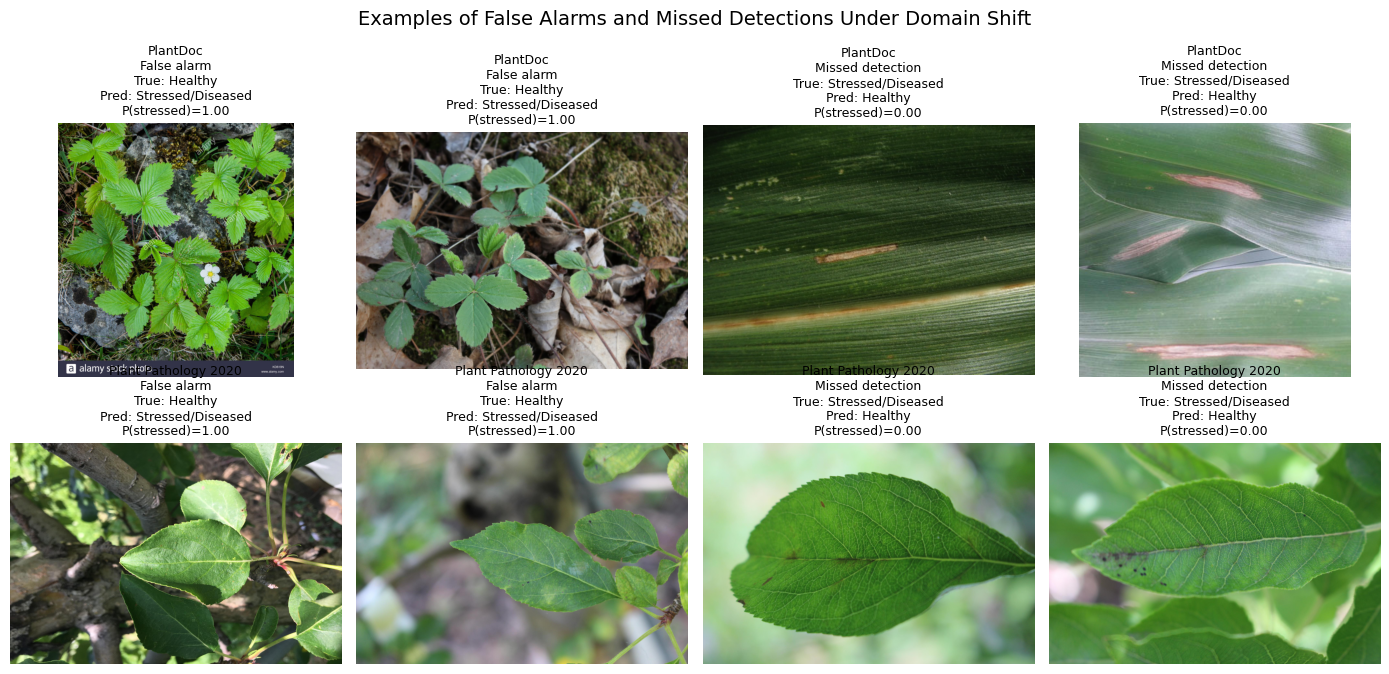

Selected examples saved at: results/selected_qualitative_error_examples.csv
Figure saved at: results/qualitative_error_examples.png
Figure saved at: paper_outputs/figures/Figure_9_qualitative_error_examples.png


In [7]:
from PIL import Image
import matplotlib.pyplot as plt

def select_error_examples(errors_df, dataset_name, error_type, n=2):
    subset = errors_df[
        (errors_df["dataset"] == dataset_name) &
        (errors_df["error_type"] == error_type)
    ].copy()

    if error_type == "False alarm":
        # Healthy predicted as diseased with high confidence
        subset = subset.sort_values("prob_stressed", ascending=False)
    else:
        # Diseased predicted as healthy with low probability of stressed
        subset = subset.sort_values("prob_stressed", ascending=True)

    return subset.head(n)

selected_examples = pd.concat([
    select_error_examples(all_errors, "PlantDoc", "False alarm", n=2),
    select_error_examples(all_errors, "PlantDoc", "Missed detection", n=2),
    select_error_examples(all_errors, "Plant Pathology 2020", "False alarm", n=2),
    select_error_examples(all_errors, "Plant Pathology 2020", "Missed detection", n=2),
], ignore_index=True)

selected_path = "results/selected_qualitative_error_examples.csv"
selected_examples.to_csv(selected_path, index=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, row in selected_examples.iterrows():
    image = Image.open(row["image_path"]).convert("RGB")

    axes[i].imshow(image)
    axes[i].axis("off")

    true_name = "Healthy" if row["true_label"] == 0 else "Stressed/Diseased"
    pred_name = "Healthy" if row["predicted_label"] == 0 else "Stressed/Diseased"

    title = (
        f"{row['dataset']}\n"
        f"{row['error_type']}\n"
        f"True: {true_name}\n"
        f"Pred: {pred_name}\n"
        f"P(stressed)={row['prob_stressed']:.2f}"
    )

    axes[i].set_title(title, fontsize=9)

plt.suptitle(
    "Examples of False Alarms and Missed Detections Under Domain Shift",
    fontsize=14
)

plt.tight_layout()

figure_path = "results/qualitative_error_examples.png"
paper_figure_path = "paper_outputs/figures/Figure_9_qualitative_error_examples.png"

plt.savefig(figure_path, dpi=300)
plt.savefig(paper_figure_path, dpi=300)

plt.show()

print("Selected examples saved at:", selected_path)
print("Figure saved at:", figure_path)
print("Figure saved at:", paper_figure_path)

Project root: C:\Users\user\Desktop\Plant_Stress_Domain_Shift
Model loaded: models/mobilenetv3_small_plantvillage_20000.pth
Device: cpu
PlantDoc: 2572
binary_label
Stressed/Diseased    1725
Healthy               847
Name: count, dtype: int64

Plant Pathology 2020: 1821
binary_label
Stressed/Diseased    1305
Healthy               516
Name: count, dtype: int64

Errors saved at: results/qualitative_error_examples.csv

PlantDoc errors:
error_type
False alarm         612
Missed detection     90
Name: count, dtype: int64

Plant Pathology 2020 errors:
error_type
False alarm         385
Missed detection     59
Name: count, dtype: int64

Selected examples saved at: results/selected_qualitative_error_examples.csv
                dataset        error_type  true_label  predicted_label  \
0              PlantDoc       False alarm           0                1   
1              PlantDoc       False alarm           0                1   
2              PlantDoc  Missed detection           1            

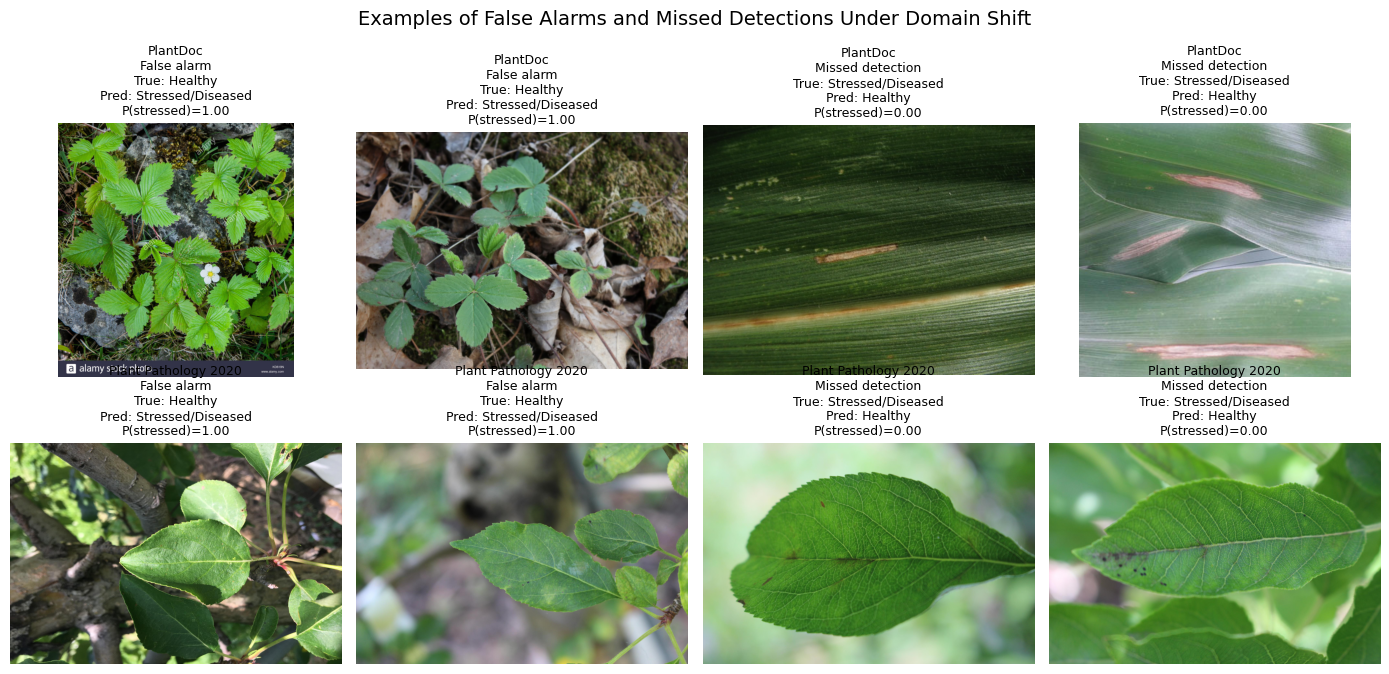


Figure saved at: results/qualitative_error_examples.png
Figure saved at: paper_outputs/figures/Figure_9_qualitative_error_examples.png


In [8]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

# Aller au dossier principal du projet
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

os.makedirs("results", exist_ok=True)
os.makedirs("paper_outputs/figures", exist_ok=True)

print("Project root:", os.getcwd())

# ==============================
# 1. Charger le modèle MobileNetV3-Small 20 000
# ==============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = MobileNet_V3_Small_Weights.DEFAULT
model = mobilenet_v3_small(weights=weights)

model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)

model_path = "models/mobilenetv3_small_plantvillage_20000.pth"
model.load_state_dict(torch.load(model_path, map_location=device))

model = model.to(device)
model.eval()

print("Model loaded:", model_path)
print("Device:", device)

# ==============================
# 2. Préparer transformation + Dataset
# ==============================

image_size = 224

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class PlantStressDatasetWithPaths(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "image_path"]
        label = int(self.dataframe.loc[index, "label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image_tensor = self.transform(image)
        else:
            image_tensor = image

        return image_tensor, label, image_path

# ==============================
# 3. Charger PlantDoc et Plant Pathology 2020
# ==============================

label_map = {
    "Healthy": 0,
    "Stressed/Diseased": 1
}

plantdoc_df = pd.read_csv("data/PlantDoc/plantdoc_binary_metadata.csv")
plantdoc_df["label"] = plantdoc_df["binary_label"].map(label_map)

pp2020_df = pd.read_csv("data/PlantPathology2020/plantpathology2020_binary_metadata.csv")
pp2020_df["label"] = pp2020_df["binary_label"].map(label_map)

print("PlantDoc:", len(plantdoc_df))
print(plantdoc_df["binary_label"].value_counts())

print("\nPlant Pathology 2020:", len(pp2020_df))
print(pp2020_df["binary_label"].value_counts())

# ==============================
# 4. Extraire les erreurs
# ==============================

def get_error_examples(dataframe, dataset_name, batch_size=16):
    dataset = PlantStressDatasetWithPaths(
        dataframe,
        transform=val_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    rows = []

    model.eval()

    with torch.no_grad():
        for images, labels, image_paths in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            for i in range(len(labels)):
                true_label = int(labels[i].cpu().item())
                predicted_label = int(predictions[i].cpu().item())
                prob_stressed = float(probabilities[i, 1].cpu().item())

                if true_label != predicted_label:
                    if true_label == 0 and predicted_label == 1:
                        error_type = "False alarm"
                    elif true_label == 1 and predicted_label == 0:
                        error_type = "Missed detection"
                    else:
                        error_type = "Other error"

                    rows.append({
                        "dataset": dataset_name,
                        "image_path": image_paths[i],
                        "true_label": true_label,
                        "predicted_label": predicted_label,
                        "prob_stressed": prob_stressed,
                        "error_type": error_type
                    })

    return pd.DataFrame(rows)

plantdoc_errors = get_error_examples(plantdoc_df, "PlantDoc")
pp2020_errors = get_error_examples(pp2020_df, "Plant Pathology 2020")

all_errors = pd.concat(
    [plantdoc_errors, pp2020_errors],
    ignore_index=True
)

errors_path = "results/qualitative_error_examples.csv"
all_errors.to_csv(errors_path, index=False)

print("\nErrors saved at:", errors_path)

print("\nPlantDoc errors:")
print(plantdoc_errors["error_type"].value_counts())

print("\nPlant Pathology 2020 errors:")
print(pp2020_errors["error_type"].value_counts())

# ==============================
# 5. Sélectionner 8 exemples
# ==============================

def select_error_examples(errors_df, dataset_name, error_type, n=2):
    subset = errors_df[
        (errors_df["dataset"] == dataset_name) &
        (errors_df["error_type"] == error_type)
    ].copy()

    if error_type == "False alarm":
        # Healthy predicted as diseased with high confidence
        subset = subset.sort_values("prob_stressed", ascending=False)
    else:
        # Diseased predicted as healthy with low probability of stressed
        subset = subset.sort_values("prob_stressed", ascending=True)

    return subset.head(n)

selected_examples = pd.concat([
    select_error_examples(all_errors, "PlantDoc", "False alarm", n=2),
    select_error_examples(all_errors, "PlantDoc", "Missed detection", n=2),
    select_error_examples(all_errors, "Plant Pathology 2020", "False alarm", n=2),
    select_error_examples(all_errors, "Plant Pathology 2020", "Missed detection", n=2),
], ignore_index=True)

selected_path = "results/selected_qualitative_error_examples.csv"
selected_examples.to_csv(selected_path, index=False)

print("\nSelected examples saved at:", selected_path)
print(selected_examples[["dataset", "error_type", "true_label", "predicted_label", "prob_stressed"]])

# ==============================
# 6. Créer Figure 9
# ==============================

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, row in selected_examples.iterrows():
    image = Image.open(row["image_path"]).convert("RGB")

    axes[i].imshow(image)
    axes[i].axis("off")

    true_name = "Healthy" if row["true_label"] == 0 else "Stressed/Diseased"
    pred_name = "Healthy" if row["predicted_label"] == 0 else "Stressed/Diseased"

    title = (
        f"{row['dataset']}\n"
        f"{row['error_type']}\n"
        f"True: {true_name}\n"
        f"Pred: {pred_name}\n"
        f"P(stressed)={row['prob_stressed']:.2f}"
    )

    axes[i].set_title(title, fontsize=9)

plt.suptitle(
    "Examples of False Alarms and Missed Detections Under Domain Shift",
    fontsize=14
)

plt.tight_layout()

figure_path = "results/qualitative_error_examples.png"
paper_figure_path = "paper_outputs/figures/Figure_9_qualitative_error_examples.png"

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.savefig(paper_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("\nFigure saved at:", figure_path)
print("Figure saved at:", paper_figure_path)